In [3]:
#import libraries
from io import StringIO
import seaborn as sns
import matplotlib.pyplot as plt
import json
sns.set(style="whitegrid", palette="muted", font_scale=1.1)


In [4]:
import requests
import pandas as pd
from bs4 import BeautifulSoup

# API URL
url = "https://www.topuniversities.com/sites/default/files/qs-rankings-data/en/3740566.txt"

headers = {
    "User-Agent": "Mozilla/5.0"
}

# Fetch data
response = requests.get(url, headers=headers)
data = response.json()

clean_data = []

# Extract & clean
for uni in data["data"]:
    
    # Clean university name (remove HTML)
    soup = BeautifulSoup(uni.get("title", ""), "html.parser")
    university_name = soup.text.strip()

    clean_data.append({
        "Rank": uni.get("rank_display"),
        "University": university_name,
        "Country": uni.get("country"),
        "Region": uni.get("region"),
        "City": uni.get("city"),
        "Overall Score": uni.get("score")
    })

# Create DataFrame
df = pd.DataFrame(clean_data)


In [5]:
# -----------------------------
# ✅ DATA CLEANING
# -----------------------------

# Clean Rank (remove '=' and convert to numeric)
df["Rank"] = df["Rank"].str.replace("=", "", regex=False)
df["Rank"] = pd.to_numeric(df["Rank"], errors="coerce")

# Convert score to numeric
df["Overall Score"] = pd.to_numeric(df["Overall Score"], errors="coerce")

# Drop missing values
df = df.dropna().reset_index(drop=True)

# -----------------------------
# ✅ FEATURE ENGINEERING
# -----------------------------

# Rank Category
df["Rank Category"] = df["Rank"].apply(
    lambda x: "Top 10" if x <= 10 else
              "Top 50" if x <= 50 else
              "Top 100" if x <= 100 else
              "Beyond 100"
    )

# Score Category
df["Score Category"] = df["Overall Score"].apply(
    lambda x: "Excellent" if x >= 90 else
              "Good" if x >= 75 else
              "Average"
)

# Continent (optional but included)
df["Continent"] = df["Region"]

# -----------------------------
# ✅ FINAL OUTPUT
# -----------------------------

print("Final Shape:", df.shape)
print(df.head())

Final Shape: (501, 9)
   Rank                                   University         Country  \
0   1.0  Massachusetts Institute of Technology (MIT)   United States   
1   2.0                         University of Oxford  United Kingdom   
2   3.0                          Stanford University   United States   
3   3.0                      University of Cambridge  United Kingdom   
4   5.0                           Harvard University   United States   

          Region       City  Overall Score Rank Category Score Category  \
0  North America  Cambridge          100.0        Top 10      Excellent   
1         Europe     Oxford           99.5        Top 10      Excellent   
2  North America   Stanford           98.7        Top 10      Excellent   
3         Europe  Cambridge           98.7        Top 10      Excellent   
4  North America  Cambridge           98.0        Top 10      Excellent   

       Continent  
0  North America  
1         Europe  
2  North America  
3         Europe  

In [6]:
# Save dataset
df.to_csv("qs_final_dataset.csv", index=False)

In [7]:
df.shape

(501, 9)

In [8]:
df.isnull().any()

Rank              False
University        False
Country           False
Region            False
City              False
Overall Score     False
Rank Category     False
Score Category    False
Continent         False
dtype: bool

In [9]:
df.isnull().sum()

Rank              0
University        0
Country           0
Region            0
City              0
Overall Score     0
Rank Category     0
Score Category    0
Continent         0
dtype: int64

In [10]:
#Top 10 Universities
df.sort_values("Rank").head(10)

,Rank,University,Country,Region,City,Overall Score,Rank Category,Score Category,Continent
0,1.0,Massachusetts Institute of Technology (MIT),United States,North America,Cambridge,100.0,Top 10,Excellent,North America
1,2.0,University of Oxford,United Kingdom,Europe,Oxford,99.5,Top 10,Excellent,Europe
2,3.0,Stanford University,United States,North America,Stanford,98.7,Top 10,Excellent,North America
3,3.0,University of Cambridge,United Kingdom,Europe,Cambridge,98.7,Top 10,Excellent,Europe
4,5.0,Harvard University,United States,North America,Cambridge,98.0,Top 10,Excellent,North America
5,6.0,California Institute of Technology (Caltech),United States,North America,Pasadena,97.4,Top 10,Excellent,North America
6,7.0,Imperial College London,United Kingdom,Europe,London,97.3,Top 10,Excellent,Europe
7,8.0,ETH Zurich,Switzerland,Europe,Zürich,95.4,Top 10,Excellent,Europe
8,8.0,UCL,United Kingdom,Europe,London,95.4,Top 10,Excellent,Europe
9,10.0,University of Chicago,United States,North America,Chicago,94.5,Top 10,Excellent,North America


In [11]:
#Country-wise count
df["Country"].value_counts().head(10)

Country
United States       87
United Kingdom      49
Germany             31
China (Mainland)    26
Australia           26
Canada              17
Russia              17
Japan               16
South Korea         16
Italy               14
Name: count, dtype: int64

In [12]:
#Region distribution
df["Region"].value_counts()

Region
Europe           212
Asia             125
North America    104
Oceania           34
Latin America     21
Africa             5
Name: count, dtype: int64

***1. UNIVARIATE ANALYSIS***

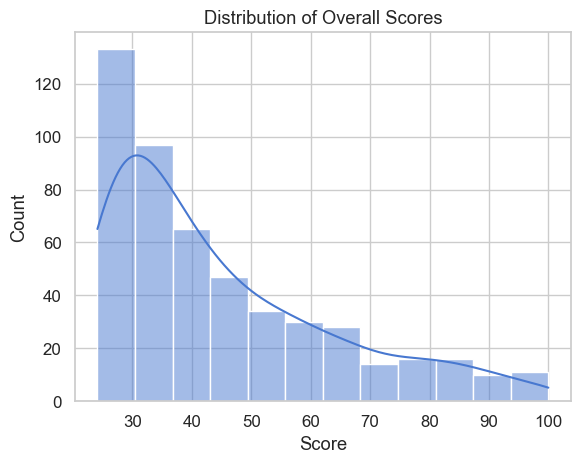

In [16]:
#Distribution of Overall Score
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["Overall Score"], kde=True)
plt.title("Distribution of Overall Scores")
plt.xlabel("Score")
plt.show()

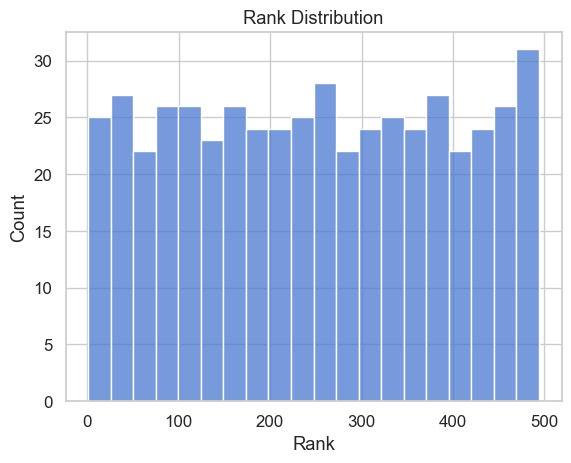

In [17]:
#Rank Distribution
sns.histplot(df["Rank"], bins=20)
plt.title("Rank Distribution")
plt.show()

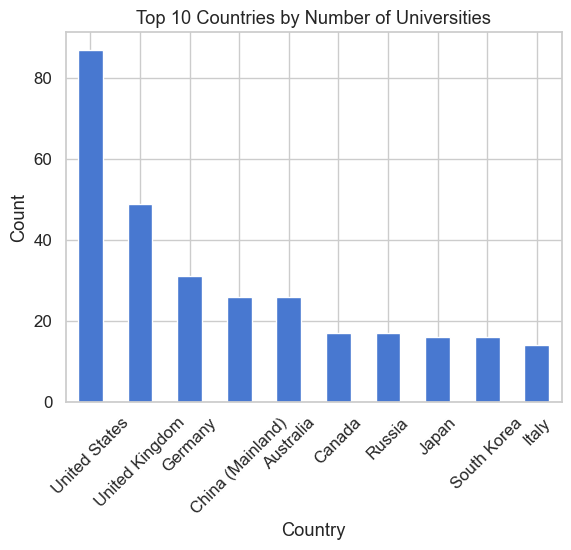

In [19]:
#Universities by Country (Top 10)
df["Country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries by Number of Universities")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

***BIVARIATE ANALYSIS***

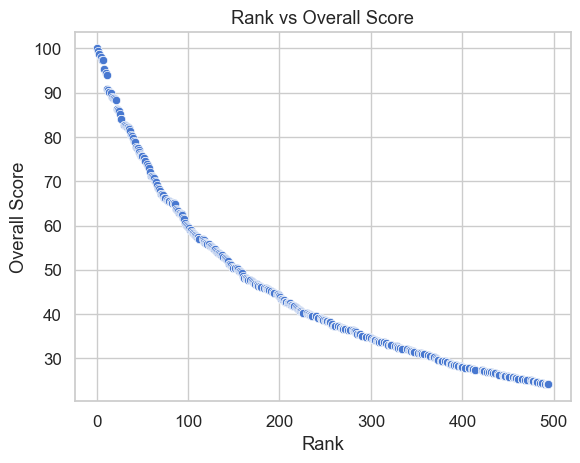

In [20]:
#Rank vs Overall Score
sns.scatterplot(x="Rank", y="Overall Score", data=df)
plt.title("Rank vs Overall Score")
plt.show()

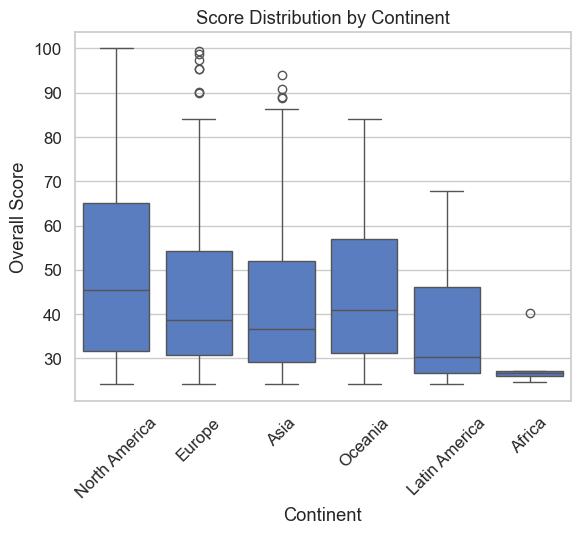

In [21]:
#Score by Continent
sns.boxplot(x="Continent", y="Overall Score", data=df)
plt.title("Score Distribution by Continent")
plt.xticks(rotation=45)
plt.show()

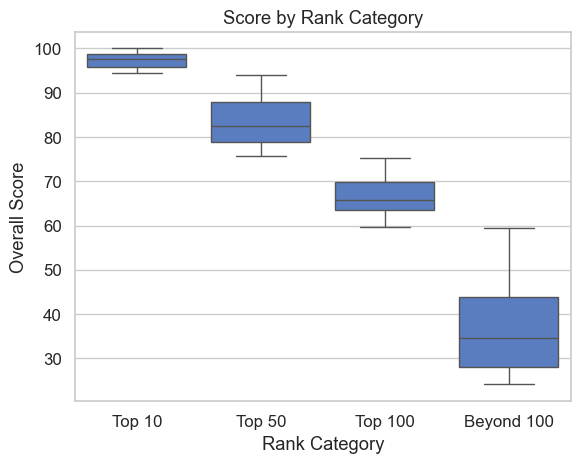

In [23]:
#Rank Category vs Score
sns.boxplot(x="Rank Category", y="Overall Score", data=df)
plt.title("Score by Rank Category")
plt.show()

***MULTIVARIATE ANALYSIS***

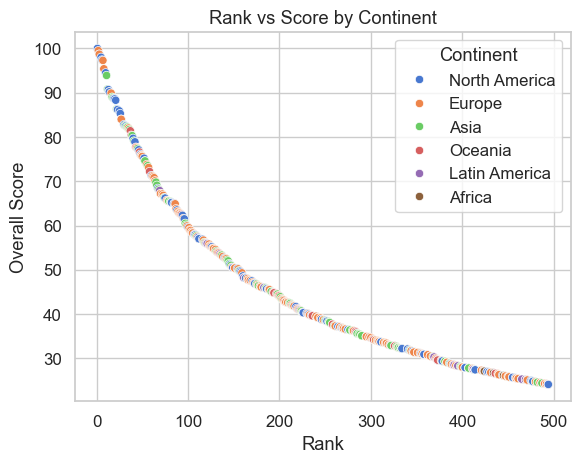

In [24]:
#Continent + Score + Rank
sns.scatterplot(x="Rank", y="Overall Score", hue="Continent", data=df)
plt.title("Rank vs Score by Continent")
plt.show()


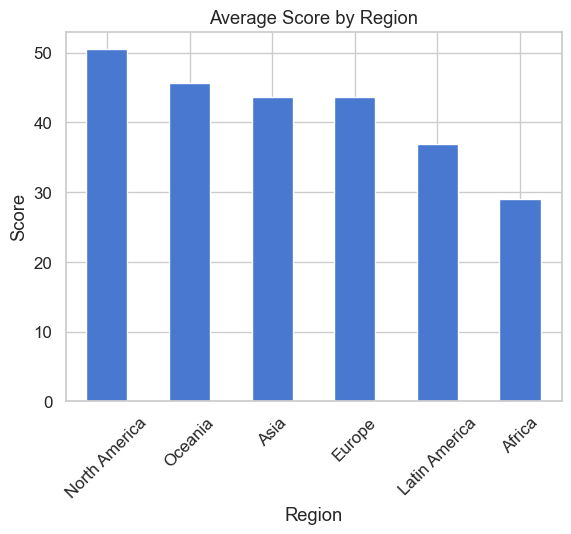

In [25]:
#Average Score by Region
df.groupby("Region")["Overall Score"].mean().sort_values(ascending=False).plot(kind="bar")
plt.title("Average Score by Region")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

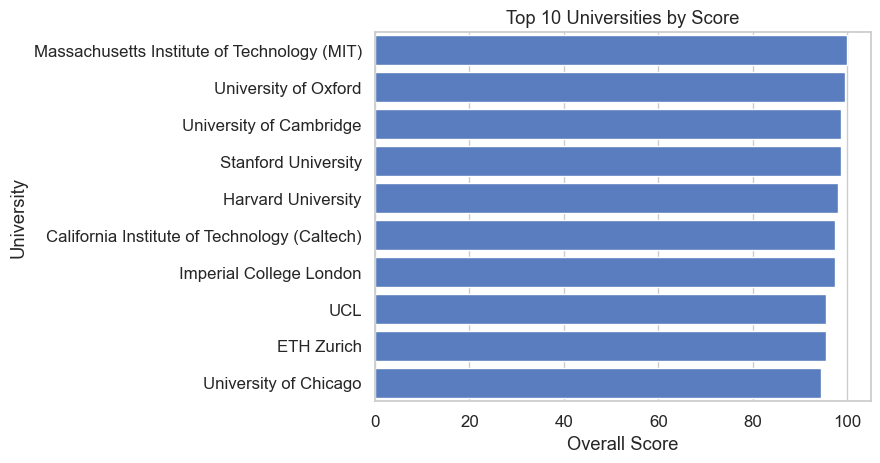

In [26]:
#Top 10 Universities
top10 = df.sort_values("Overall Score", ascending=False).head(10)

sns.barplot(x="Overall Score", y="University", data=top10)
plt.title("Top 10 Universities by Score")
plt.show()

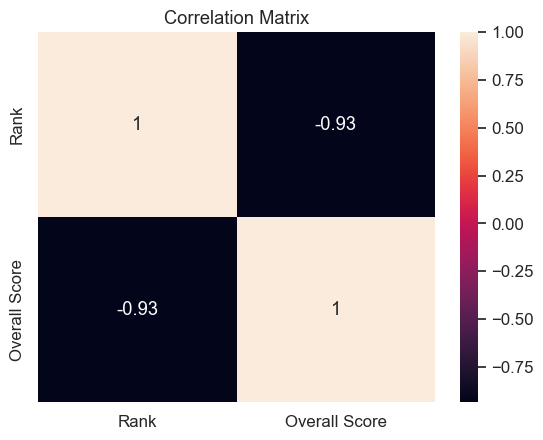

In [27]:
#Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

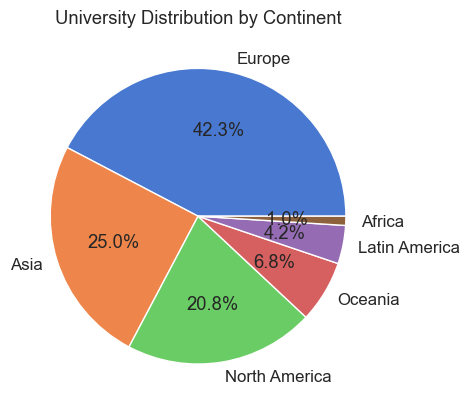

In [28]:
#Continent Distribution
df["Continent"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("University Distribution by Continent")
plt.ylabel("")
plt.show()

In [29]:
# Check missing values
df.isnull().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert Rank to numeric
df["Rank"] = pd.to_numeric(df["Rank"], errors='coerce')

# Standardize text columns
df["Country"] = df["Country"].str.strip()
df["Continent"] = df["Continent"].str.strip()

In [31]:
df.rename(columns={"Rank": "university_rank"}, inplace=True)

In [32]:
df.to_csv("clean_university_data.csv", index=False)